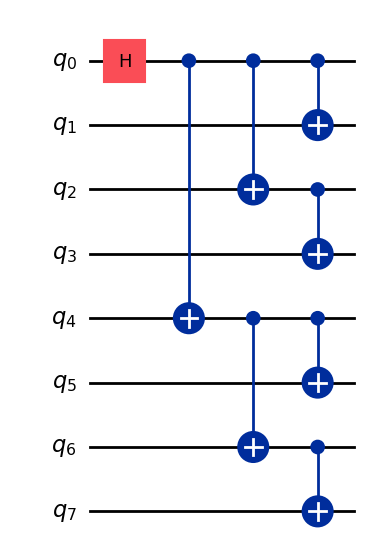

In [1]:
from qiskit import QuantumCircuit
# Build a compact GHZ(8) circuit (tree-like to keep depth small)

qc = QuantumCircuit(8)
qc.h(0)
qc.cx(0, 4)
qc.cx(0, 2)
qc.cx(4, 6)
qc.cx(0, 1)
qc.cx(2, 3)
qc.cx(4, 5)
qc.cx(6, 7)

qc.draw(output="mpl")

In [ ]:
from pathlib import Path
import tempfile
import os
from mqt.qmap.hybrid_mapper import NeutralAtomHybridArchitecture

# Create a minimal architecture from an in-code JSON string and instantiate
# the NeutralAtomHybridArchitecture using a temporary file. The mapper's
# constructor expects a filename, so we write the JSON to a temp file first.
arch_json = '''{
  "name": "example arch",
  "properties": {
    "nRows": 5,
    "nColumns": 5,
    "nAods": 1,
    "nAodCoordinates": 1,
    "interQubitDistance": 10,
    "minimalAodDistance": 0.1,
    "interactionRadius": 1,
    "blockingFactor": 1
  },
  "parameters": {
    "nQubits": 10,
    "gateTimes": {
      "none": 0.5
    },
    "gateAverageFidelities": {
      "none": 0.999
    },
    "decoherenceTimes": {
      "t1": 100000000,
      "t2": 1500000
    },
    "shuttlingTimes": {
      "move": 0.55,
      "aod_move": 0.55,
      "aod_activate": 20,
      "aod_deactivate": 20
    },
    "shuttlingAverageFidelities": {
      "move": 1,
      "aod_move": 1,
      "aod_activate": 1,
      "aod_deactivate": 1
    }
  }
}'''

with tempfile.NamedTemporaryFile(mode="w", delete=False, suffix=".json") as _tmp:
    _tmp.write(arch_json)
    tmp_name = _tmp.name

arch = NeutralAtomHybridArchitecture(tmp_name)
# Clean up the temporary file
os.unlink(tmp_name)

print(f"Loaded architecture: {arch.name} with {arch.num_qubits} qubits.")

In [ ]:
from mqt.core import load
from mqt.qmap.hybrid_mapper import HybridNAMapper, MapperParameters

# Optional: tweak parameters (defaults are sensible for most cases)
params_shuttling = MapperParameters()
params_shuttling.gate_weight = 1.0
params_shuttling.shuttling_weight = 0.0  # disables atom moves


mapper = HybridNAMapper(arch, params=params_shuttling)

# Convert the Qiskit circuit to an MQT QuantumComputation and map it
circ = load(qc)
mapper.map(circ)  # optionally: mapper.map(circ, initial_mapping=InitialCircuitMapping.identity)

# Retrieve mapping statistics
mapper.get_stats()

In [ ]:
params_default = MapperParameters()

mapper.set_parameters(params_default)

mapper.map(circ)
mapper.get_stats()

In [ ]:
params_default = MapperParameters()

mapper.set_parameters(params_default)

mapper.map(circ)
mapper.get_stats()

In [ ]:
# Schedule; set create_animation_csv=True to generate visualization data
results = mapper.schedule(verbose=True, create_animation_csv=False)

results

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit.transpiler import CouplingMap

# ----------------------------------------------------
# 1. Create a simple quantum circuit
# ----------------------------------------------------
qc = QuantumCircuit(3)

qc.h(0)
qc.cx(0, 2)
qc.cx(2, 1)

print("Original circuit:")
print(qc.draw())

# ----------------------------------------------------
# 2. Define a coupling map (linear device)
# 0 -> 1 -> 2
# ----------------------------------------------------
coupling_map = CouplingMap([
    [0, 1],
    [1, 2]
])

# ----------------------------------------------------
# 3. Transpile the circuit
# ----------------------------------------------------
transpiled_qc = transpile(
    qc,
    coupling_map=coupling_map,
    basis_gates=['u3', 'cx'],
    optimization_level=1
)

print("\nTranspiled circuit:")
print(transpiled_qc.draw())

# ----------------------------------------------------
# 4. Extract circuit statistics
# ----------------------------------------------------
print("\n--- Circuit Statistics ---")

# Gate counts
gate_counts = transpiled_qc.count_ops()
print("Gate counts:", gate_counts)

# Depth
print("Circuit depth:", transpiled_qc.depth())

# Total number of gates
print("Circuit size:", transpiled_qc.size())

# Width (number of qubits used)
print("Circuit width:", transpiled_qc.width())

# Number of qubits and classical bits
print("Number of qubits:", transpiled_qc.num_qubits)
print("Number of classical bits:", transpiled_qc.num_clbits)

# Two-qubit gate count (CX)
print("CX gate count:", gate_counts.get('cx', 0))

# Layout (logical → physical qubit mapping)
print("Qubit layout:", transpiled_qc.layout)

# ----------------------------------------------------
# 5. Optional: stats after full decomposition
# ----------------------------------------------------
print("\nDecomposed gate counts:")
print(transpiled_qc.decompose().count_ops())


In [ ]:
import pennylane as qml
dev = qml.device("default.qubit")
@qml.qnode(dev)
def circuit():
    qml.Y(0)
    qml.X(1)
    qml.Z(2)
    qml.Hadamard(wires=6)
    qml.Hadamard(wires=1)
    return qml.density_matrix([0,1])

print(qml.draw(circuit)())
print(circuit())

0: ──Y─┤ ╭DensityMatrix
1: ──H─┤ ╰DensityMatrix
[[0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0.5+0.j 0.5+0.j]
 [0. +0.j 0. +0.j 0.5+0.j 0.5+0.j]]
